In [1]:
import pandas as pd

In [2]:
titanic_df = pd.read_csv("../data/titanic.csv")

titanic_df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [3]:
titanic_df.isnull().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

In [4]:
titanic_df["age"] = titanic_df["age"].fillna(
    titanic_df["age"].median()
)

In [5]:
titanic_df["embarked"] = titanic_df["embarked"].fillna(
    titanic_df["embarked"].mode()[0]
)

In [6]:
titanic_df["embark_town"] = titanic_df["embark_town"].fillna(
    titanic_df["embark_town"].mode()[0]
)

In [7]:
titanic_df.drop(
    "deck",
    axis=1,
    inplace=True
)

In [8]:
titanic_df.drop(
    [
        "alive",
        "class",
        "who",
        "adult_male",
        "embark_town"
    ],
    axis=1,
    inplace=True
)

In [9]:
titanic_df["sex"] = titanic_df["sex"].map(
    {
        "male":0,
        "female":1
    }
)

In [10]:
titanic_df = pd.get_dummies(
    titanic_df,
    columns=["embarked"],
    drop_first=True
)

In [11]:
titanic_df["alone"] = titanic_df["alone"].astype(int)

In [12]:
X = titanic_df.drop(
    "survived",
    axis=1
)

y = titanic_df["survived"]

In [13]:
from sklearn.model_selection import train_test_split

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [15]:
from xgboost import XGBClassifier

In [17]:
from xgboost import XGBClassifier

In [18]:
xgb_model = XGBClassifier(
    random_state=42
)

In [19]:
xgb_model.fit(X_train, y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [20]:
y_pred = xgb_model.predict(X_test)

In [21]:
print(y_pred[:10])

[0 0 1 1 1 1 1 0 0 1]


In [22]:
from sklearn.metrics import accuracy_score

In [23]:
accuracy = accuracy_score(
    y_test,
    y_pred
)

print("Accuracy:", accuracy)

Accuracy: 0.8044692737430168


In [24]:
from sklearn.metrics import confusion_matrix

In [25]:
cm = confusion_matrix(
    y_test,
    y_pred
)

cm

array([[89, 16],
       [19, 55]])

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

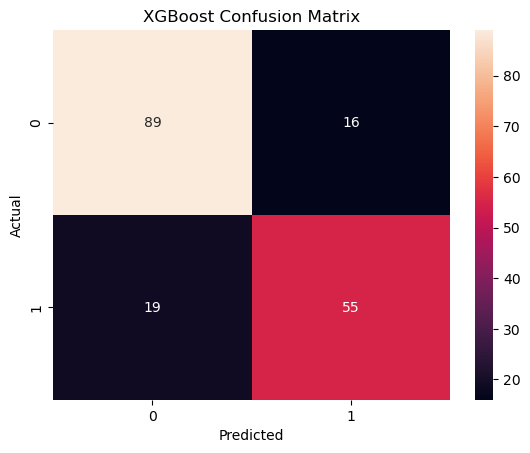

In [27]:
sns.heatmap(
    cm,
    annot=True,
    fmt="d"
)

plt.title("XGBoost Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [28]:
from sklearn.metrics import classification_report

In [29]:
print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       0.82      0.85      0.84       105
           1       0.77      0.74      0.76        74

    accuracy                           0.80       179
   macro avg       0.80      0.80      0.80       179
weighted avg       0.80      0.80      0.80       179

